<a href="https://colab.research.google.com/github/khalidkhankakar/Hands-on-Machine-Learning/blob/master/training_neural_network/training_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Training Neural Network


### Vanishing and Expolding

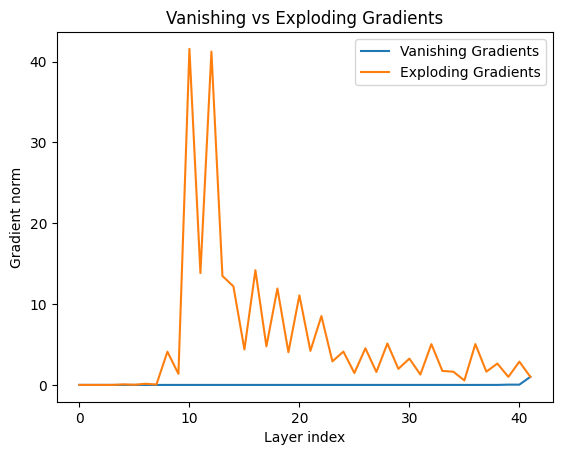

In [4]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# The problem
class DeepNN(nn.Module):
  def __init__(self, depth=10, width=32):
    super().__init__()

    layers = []
    for _ in range(depth):
      layers.append(nn.Linear(width, width))
      layers.append(nn.Tanh())

    layers.append(nn.Linear(width, 1))

    self.net = nn.Sequential(*layers)

  def forward(self, x):
    return self.net(x)


# Function to track gradient norms
def track_gradients(model, input_tensor):
    output = model(input_tensor)
    loss = output.mean()
    loss.backward()

    grad_norms = []
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_norms.append(param.grad.norm().item())
    return grad_norms

# Settings
depth = 20
width = 10
x = torch.randn(1, width)

# Case 1: Vanishing gradients (small weights)
model_vanish = DeepNN(depth, width)
for p in model_vanish.parameters():
    nn.init.normal_(p, mean=0, std=0.01)

vanish_grads = track_gradients(model_vanish, x)

# Case 2: Exploding gradients (large weights)
model_explode = DeepNN(depth, width)
for p in model_explode.parameters():
    nn.init.normal_(p, mean=0, std=1.5)

explode_grads = track_gradients(model_explode, x)

# Plot
plt.figure()
plt.plot(vanish_grads, label="Vanishing Gradients")
plt.plot(explode_grads, label="Exploding Gradients")
plt.xlabel("Layer index")
plt.ylabel("Gradient norm")
plt.legend()
plt.title("Vanishing vs Exploding Gradients")
plt.show()

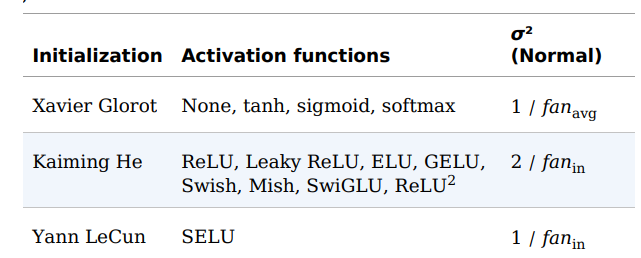

/tmp/ipykernel_1704/2527304023.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


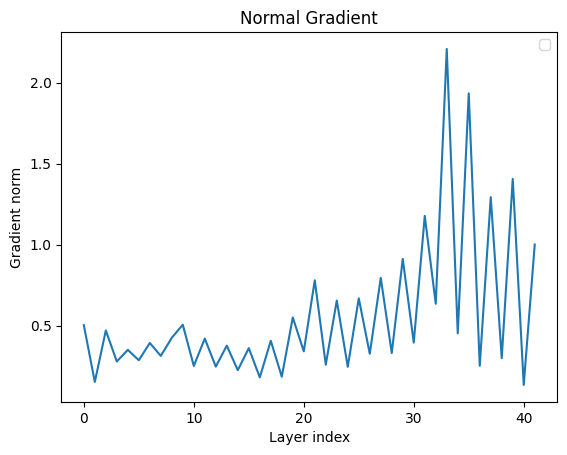

In [24]:
# Solution
model = DeepNN(depth, width)
for name, param in model.named_parameters():
  if 'weight' in name:
    nn.init.xavier_normal_(param)
  else:
    nn.init.zeros_(param)

grads = track_gradients(model, x)
plt.figure()
plt.plot(grads)
plt.xlabel("Layer index")
plt.ylabel("Gradient norm")
plt.legend()
plt.title("Normal Gradient")
plt.show()

# Note
# nn.ReLU + Kaiming
# nn.Tanh() + Xavier

### Leaky ReLU
Having z < 0 ensure that it never actually die but goes in long coma and have chance to eventually wake up.


*   **RReLU**:-  where α is picked randomly in
a given range during training and is fixed to an average value
during testing. RReLU also performed fairly well an
*   **PReLU**:- where α is
authorized to be learned during training: instead of being a
hyperparameter, it becomes a parameter that can be modified
by backpropagation like any other parameter. PReLU was
reported to strongly outperform ReLU on large image datasets,
but on small




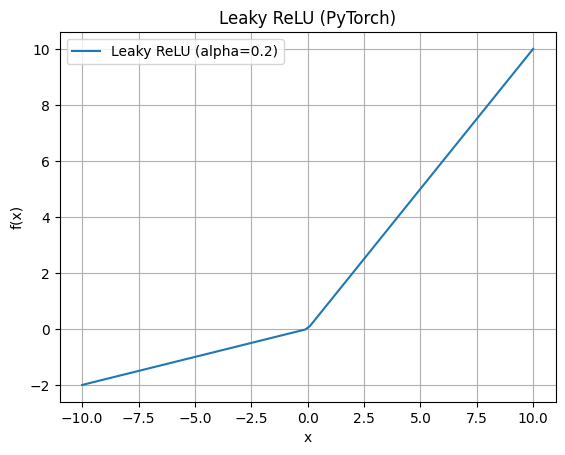

In [36]:
import torch.nn.functional as F

def leaky_relu(x, a):

  return F.leaky_relu(x, negative_slope=a) # torch.where(x > 0, x , x * a)

alpha = 0.2
x = torch.linspace(-10, 10, 100)
y = leaky_relu(x, alpha)

plt.figure()
plt.plot(x, y, label=f"Leaky ReLU (alpha={alpha})")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Leaky ReLU (PyTorch)")
plt.legend()
plt.grid()
plt.show()